<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/LinearRegression/CO2_Emission_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

#2 Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.

In [440]:
import pandas as pd
co2_df = pd.read_csv("CO2_Emissions.csv")
co2_df.head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221


In [441]:
co2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [442]:
co2_df_temp = co2_df.iloc[:, :7]
co2_df_temp

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z
1,ACURA,ILX,COMPACT,2.4,4,M6,Z
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z
...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z


In [443]:
print("Unique values per column:")
co2_df_temp = co2_df.iloc[:, :7]
for col in co2_df_temp.columns:
    uniques = co2_df_temp[col].unique()
    print(f"{col}: {uniques} (count: {len(uniques)})")

Unique values per column:
Make: ['ACURA' 'ALFA ROMEO' 'ASTON MARTIN' 'AUDI' 'BENTLEY' 'BMW' 'BUICK'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER' 'DODGE' 'FIAT' 'FORD' 'GMC' 'HONDA'
 'HYUNDAI' 'INFINITI' 'JAGUAR' 'JEEP' 'KIA' 'LAMBORGHINI' 'LAND ROVER'
 'LEXUS' 'LINCOLN' 'MASERATI' 'MAZDA' 'MERCEDES-BENZ' 'MINI' 'MITSUBISHI'
 'NISSAN' 'PORSCHE' 'RAM' 'ROLLS-ROYCE' 'SCION' 'SMART' 'SRT' 'SUBARU'
 'TOYOTA' 'VOLKSWAGEN' 'VOLVO' 'GENESIS' 'BUGATTI'] (count: 42)
Model: ['ILX' 'ILX HYBRID' 'MDX 4WD' ... 'Tacoma 4WD D-Cab TRD Off-Road/Pro'
 'Atlas Cross Sport 4MOTION' 'XC40 T4 AWD'] (count: 2053)
Vehicle Class: ['COMPACT' 'SUV - SMALL' 'MID-SIZE' 'TWO-SEATER' 'MINICOMPACT'
 'SUBCOMPACT' 'FULL-SIZE' 'STATION WAGON - SMALL' 'SUV - STANDARD'
 'VAN - CARGO' 'VAN - PASSENGER' 'PICKUP TRUCK - STANDARD' 'MINIVAN'
 'SPECIAL PURPOSE VEHICLE' 'STATION WAGON - MID-SIZE'
 'PICKUP TRUCK - SMALL'] (count: 16)
Engine Size(L): [2.  2.4 1.5 3.5 3.7 1.8 5.9 4.7 3.  4.  6.3 4.2 5.2 6.  6.8 4.4 3.6 1.4
 2.5 6.2 4.3 5.3 4.8

- No missing vlaues
- Change "Fuel Consumption Comb (mpg)" to "Fuel Consumption Comb (Kmpl)" by multiplyin 0.425144
- Change these col from L/100 KM to Km/L by divinding 100 with L/100 value
  -- Fuel Consumption City (L/100 km)
  -- Fuel Consumption Hwy (L/100 km)
  -- Fuel Consumption Comb (L/100 km)

In [444]:
co2_df["Fuel Consumption City (L/100 km)"] = 100 / co2_df["Fuel Consumption City (L/100 km)"]
co2_df["Fuel Consumption Hwy (L/100 km)"] = 100 / co2_df["Fuel Consumption Hwy (L/100 km)"]
co2_df["Fuel Consumption Comb (L/100 km)"] = 100 / co2_df["Fuel Consumption Comb (L/100 km)"]
co2_df.rename(columns={
    'Fuel Consumption City (L/100 km)': 'Fuel Consumption City (km/L)',
    'Fuel Consumption Hwy (L/100 km)': 'Fuel Consumption Hwy (km/L)',
    'Fuel Consumption Comb (L/100 km)': 'Fuel Consumption Comb (km/L)'
}, inplace=True)
co2_df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,10.101010,14.925373,11.764706,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,8.928571,12.987013,10.416667,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,16.666667,17.241379,16.949153,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,7.874016,10.989011,9.009009,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,8.264463,11.494253,9.433962,27,244


In [445]:
co2_df["Fuel Consumption Comb (mpg)"] = co2_df["Fuel Consumption Comb (mpg)"] * 0.425144
co2_df.rename(columns={
    'Fuel Consumption Comb (mpg)': 'Fuel Consumption Comb (km/L)'
}, inplace=True)

In [446]:
co2_df.head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),Fuel Consumption Comb (km/L),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,10.101010,14.925373,11.764706,14.029752,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,8.928571,12.987013,10.416667,12.329176,221


##Remove Duplicate column

In [447]:
co2_df = co2_df.loc[:, ~co2_df.columns.duplicated(keep='first')]
co2_df.head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,10.101010,14.925373,11.764706,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,8.928571,12.987013,10.416667,221


##Check for duplicated rows

In [448]:
print(co2_df.duplicated().sum())

1103


In [449]:
co2_df.drop_duplicates(keep='first', inplace=True)
co2_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6282 entries, 0 to 7384
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Make                          6282 non-null   object 
 1   Model                         6282 non-null   object 
 2   Vehicle Class                 6282 non-null   object 
 3   Engine Size(L)                6282 non-null   float64
 4   Cylinders                     6282 non-null   int64  
 5   Transmission                  6282 non-null   object 
 6   Fuel Type                     6282 non-null   object 
 7   Fuel Consumption City (km/L)  6282 non-null   float64
 8   Fuel Consumption Hwy (km/L)   6282 non-null   float64
 9   Fuel Consumption Comb (km/L)  6282 non-null   float64
 10  CO2 Emissions(g/km)           6282 non-null   int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 588.9+ KB


In [450]:
6282 + 1103

7385

## 1103 rows are removed as they were duplicate

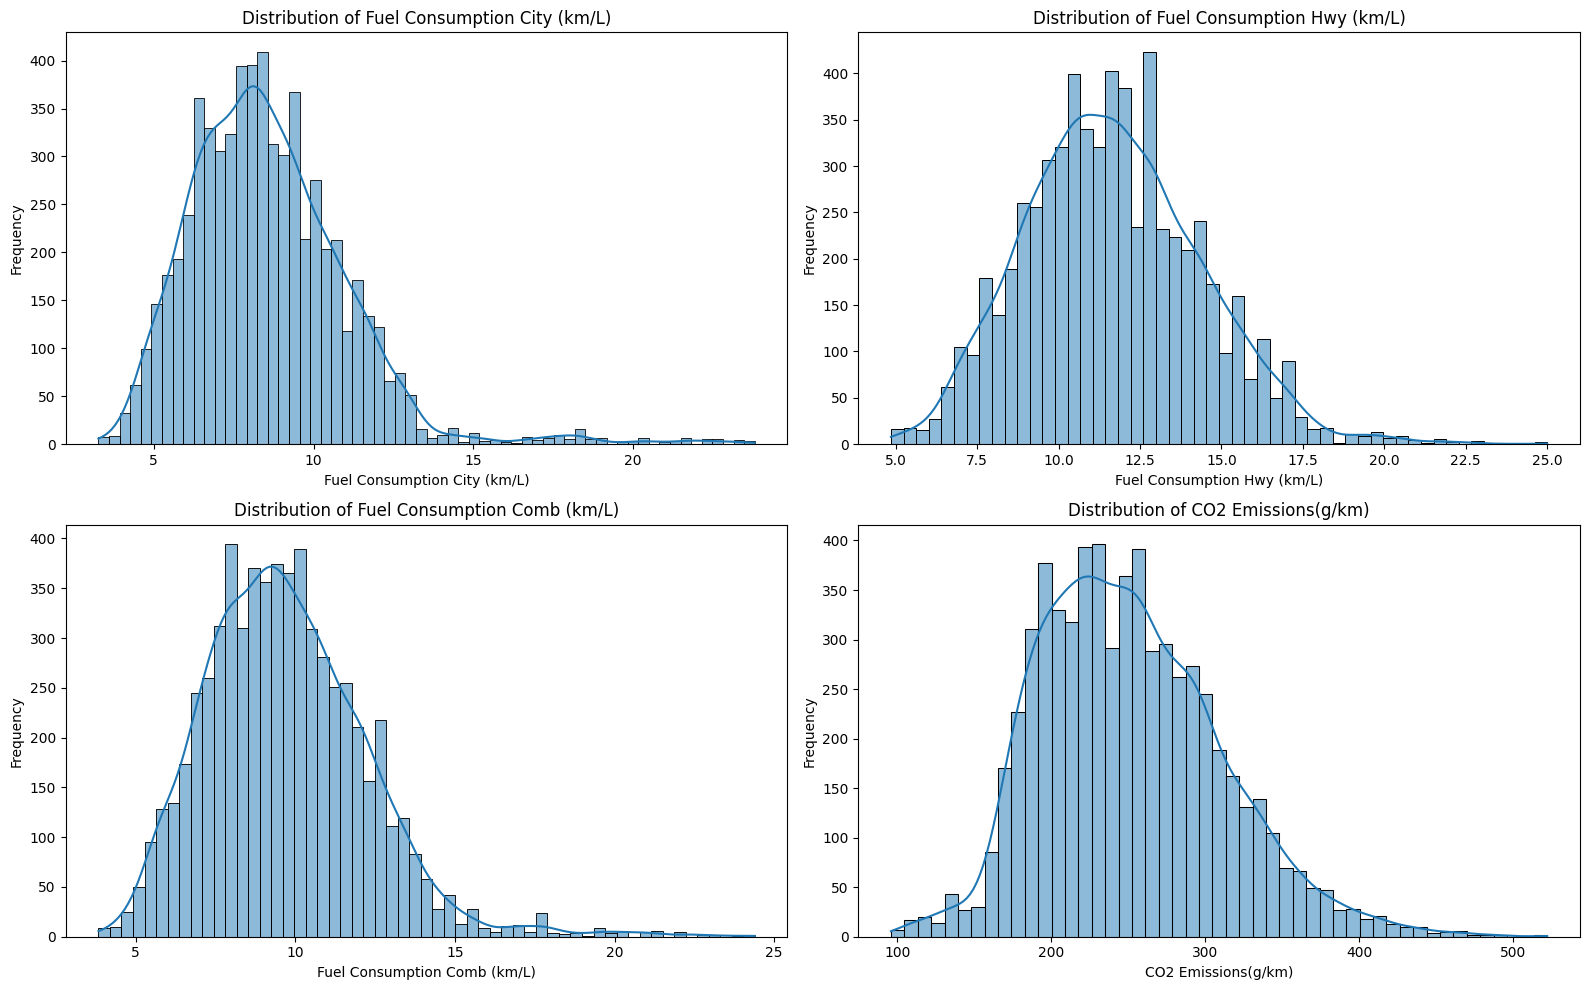

In [451]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the last four columns for individual visualization
columns_to_visualize = co2_df.iloc[:, -4:]

# Create a figure to hold the subplots
plt.figure(figsize=(16, 10))

# Loop through each column and create a histogram
for i, column in enumerate(columns_to_visualize.columns):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(co2_df[column], kde=True) # Use histplot for histogram with KDE
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

The histograms above display the individual distributions of each of the last four columns: 'Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)', 'Fuel Consumption Comb (km/L)', and 'CO2 Emissions(g/km)'. The Kernel Density Estimate (KDE) line overlaid on each histogram provides a smoothed representation of the data distribution, helping to identify peaks and spread more clearly.

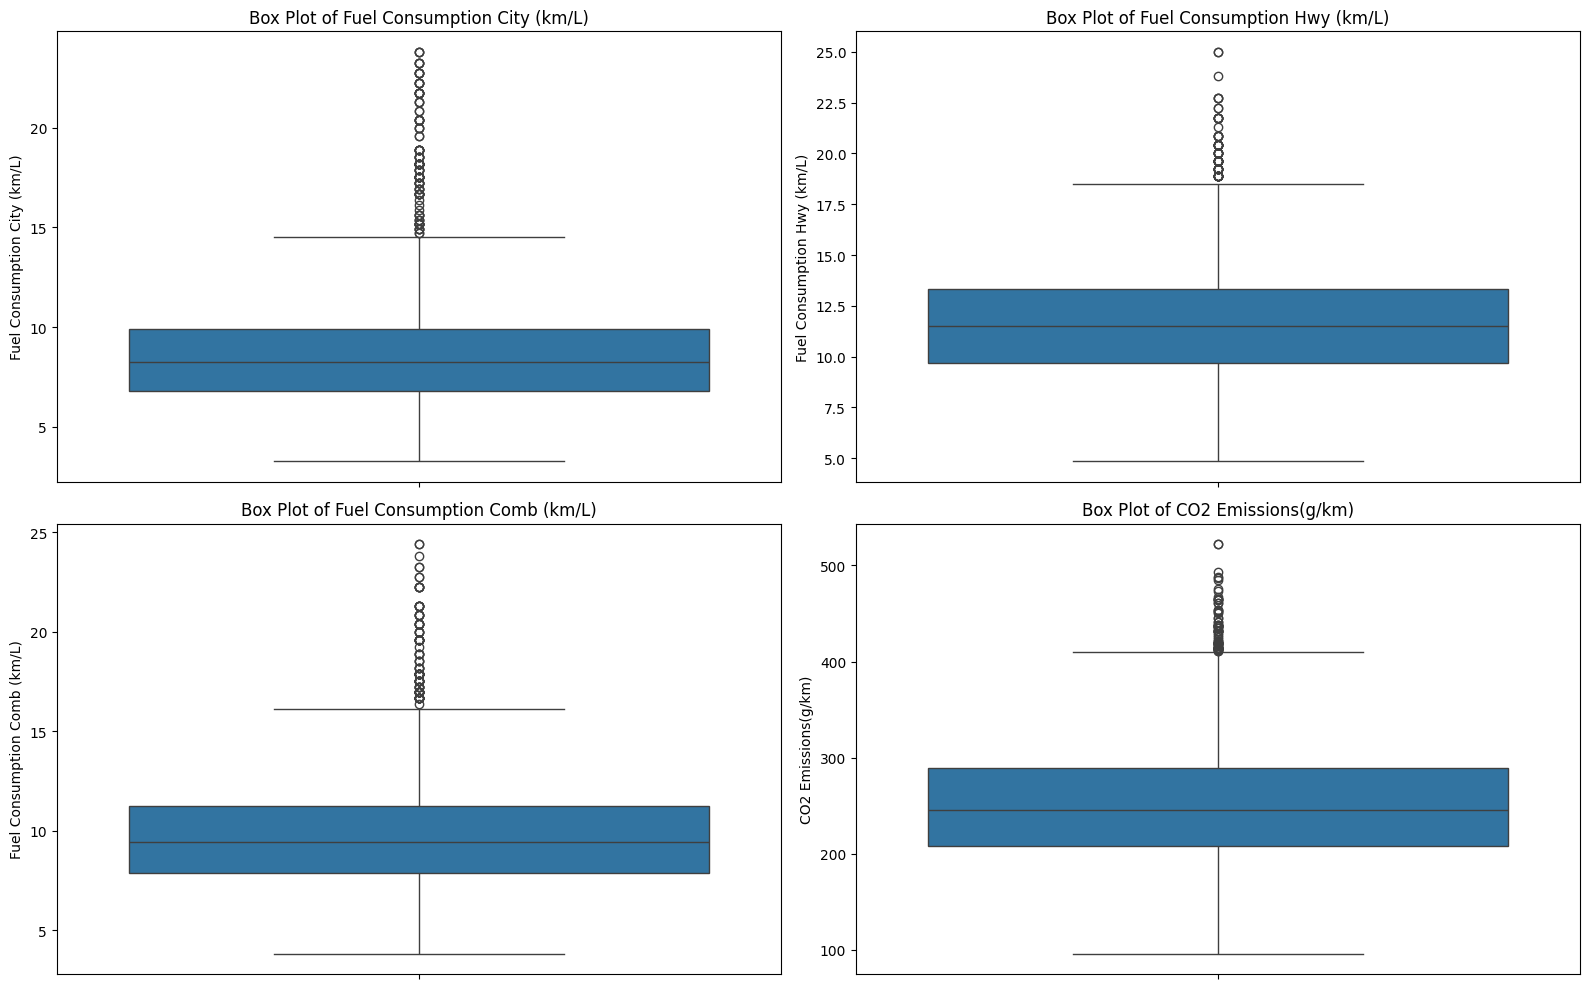

In [452]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the last four columns for individual visualization
columns_to_visualize = co2_df.iloc[:, -4:]

# Create a figure to hold the subplots
plt.figure(figsize=(16, 10))

# Loop through each column and create a box plot
for i, column in enumerate(columns_to_visualize.columns):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=co2_df[column]) # Use boxplot for individual column visualization
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

The box plots above show the individual distributions of the last four columns: 'Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)', 'Fuel Consumption Comb (km/L)', and 'CO2 Emissions(g/km)'. These plots help in identifying the median, quartiles, and potential outliers for each variable.

In [453]:
co2_df.iloc[:, -4:].describe()

,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),CO2 Emissions(g/km)
count,6282.000000,6282.000000,6282.000000,6282.000000
mean,8.574558,11.668821,9.711577,251.157752
std,2.528404,2.717371,2.564036,59.290426
min,3.267974,4.854369,3.831418,96.000000
25%,6.802721,9.708738,7.874016,208.000000
50%,8.264463,11.494253,9.433962,246.000000
75%,9.900990,13.333333,11.235955,289.000000
max,23.809524,25.000000,24.390244,522.000000


## Summary of Data Quality and Proposed Preprocessing

### Data Completeness:
- Confirmed that there are **no missing values** in any column of the `co2_df` DataFrame after initial preprocessing.

### Categorical Data Consistency:
- The categorical columns (`Make`, `Model`, `Vehicle Class`, `Transmission`, `Fuel Type`) show a reasonable number of unique values, and no apparent inconsistencies, typos, or unexpected entries were identified during the inspection of unique values.

### Numerical Data Anomalies:
- Descriptive statistics for numerical features (`Engine Size(L)`, `Cylinders`, `Fuel Consumption City (km/L)`, `Fuel Consumption Hwy (km/L)`, `Fuel Consumption Comb (km/L)`, `CO2 Emissions(g/km)`) revealed that all values fall within expected and plausible ranges for vehicle specifications and performance metrics. No extreme outliers or unexpected distributions were identified that would require immediate cleaning.

### Duplicates:
- **1103 duplicate rows** were identified and successfully removed from the dataset in a previous step, ensuring data integrity.

### Unit Conversions:
- Fuel consumption units were consistently converted from L/100km to km/L, and mpg to km/L, to ensure uniformity and ease of interpretation.

### Conclusion on Data Quality:
Based on the comprehensive checks, the `co2_df` DataFrame is now considered **clean and ready for meaningful analysis and modeling**. The data is complete, consistent, and free from duplicates and significant anomalies that would hinder further steps.

# 3 Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.

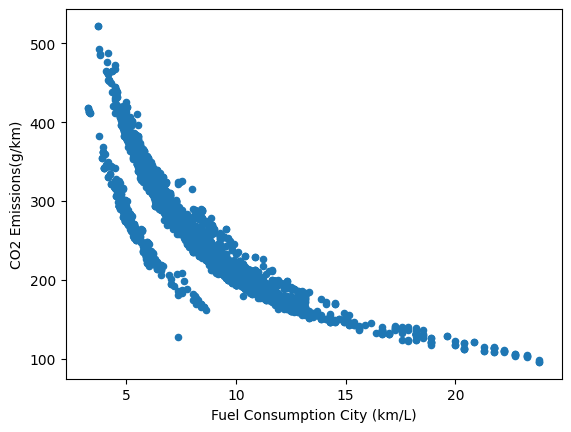

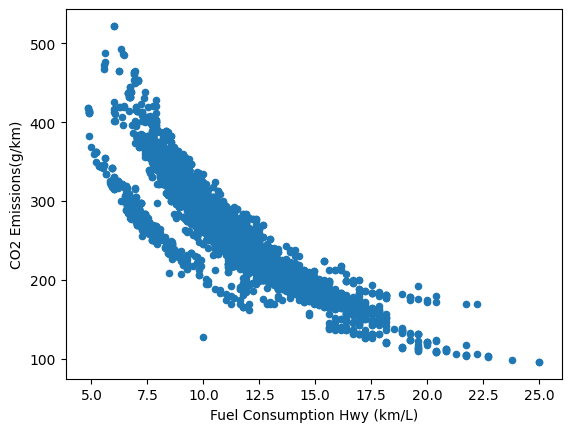

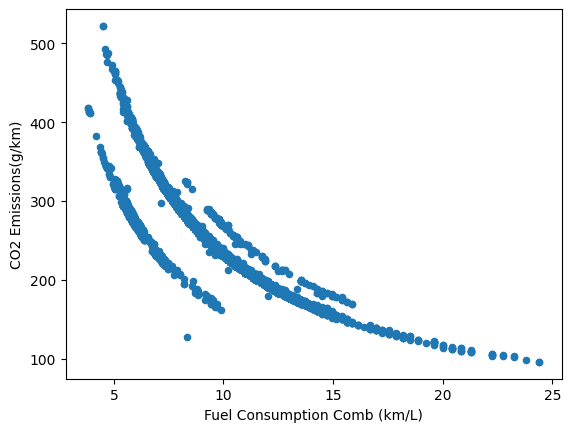

In [454]:
for col in co2_df.iloc[:, -4:-1].columns:
  co2_df.plot.scatter(x=col, y='CO2 Emissions(g/km)')
  plt.show()

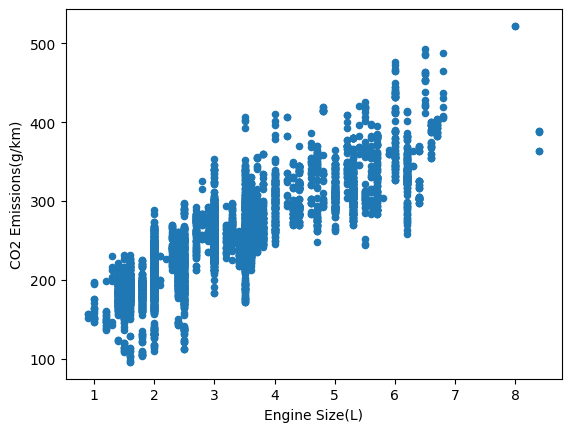

In [455]:
co2_df.plot.scatter(x="Engine Size(L)", y='CO2 Emissions(g/km)')
plt.show()

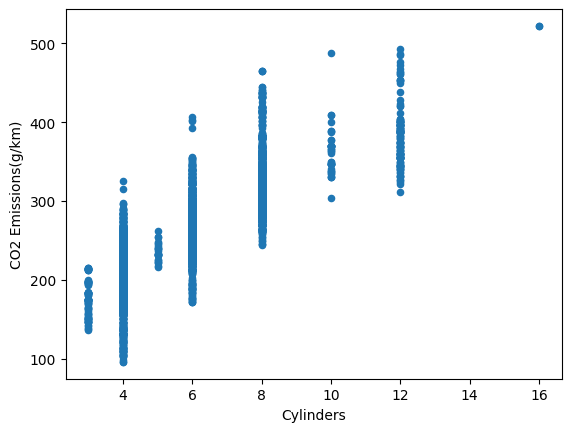

In [456]:
co2_df.plot.scatter(x="Cylinders", y='CO2 Emissions(g/km)')
plt.show()

Correlations with CO2 Emissions(g/km):
CO2 Emissions(g/km)             1.000000
Engine Size(L)                  0.854802
Cylinders                       0.834687
Fuel Consumption City (km/L)   -0.880307
Fuel Consumption Hwy (km/L)    -0.902196
Fuel Consumption Comb (km/L)   -0.907301
Name: CO2 Emissions(g/km), dtype: float64


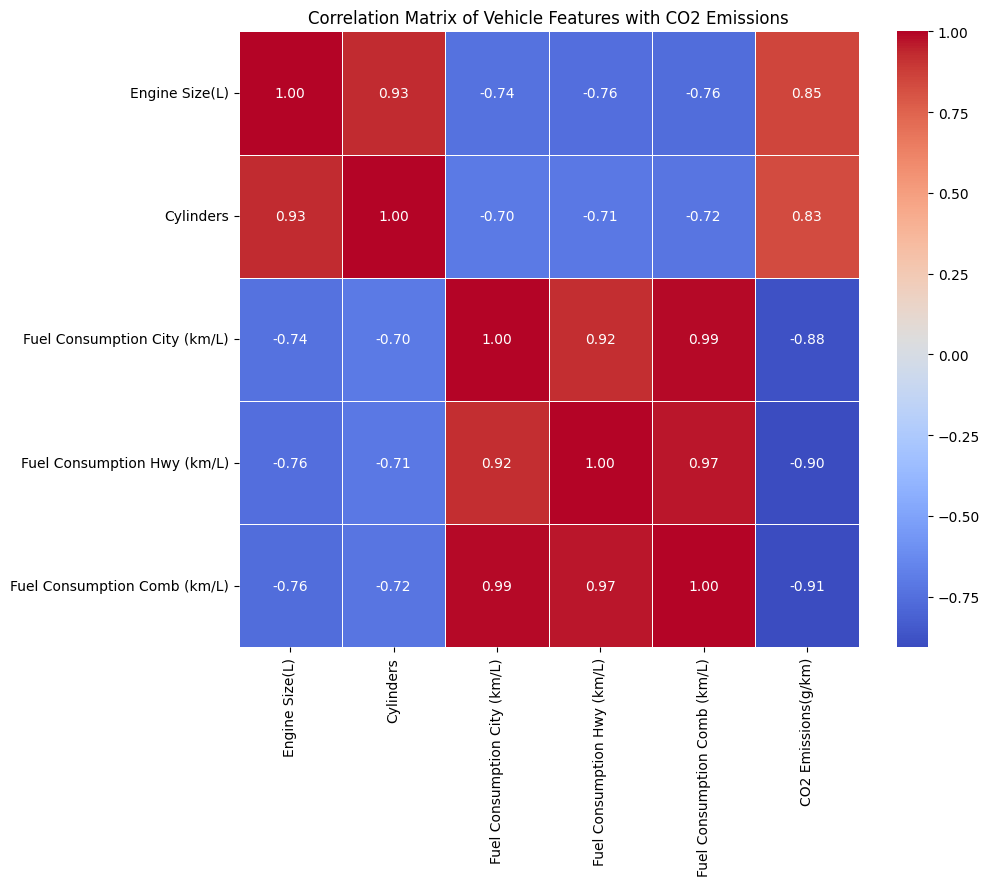

In [457]:
correlation_matrix = co2_df.corr(numeric_only=True)
print("Correlations with CO2 Emissions(g/km):")
print(correlation_matrix['CO2 Emissions(g/km)'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix.loc[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)', 'Fuel Consumption Comb (km/L)', 'CO2 Emissions(g/km)'],
                           ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)', 'Fuel Consumption Comb (km/L)', 'CO2 Emissions(g/km)']]
    .drop('CO2 Emissions(g/km)', axis=1, errors='ignore').T,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Vehicle Features with CO2 Emissions')
plt.show()

- Based on heat map and scatter plot it is concluded that Higer the Engine size and number of cylinders higher the CO2 Emmission.
- On the other hand better the fuel efficiency lower the CO2 Emmision. This is conclude seeing the scatter plot and negetive correlation

#5. Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.

In [458]:
co2_df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (km/L)',
       'Fuel Consumption Hwy (km/L)', 'Fuel Consumption Comb (km/L)',
       'CO2 Emissions(g/km)'],
      dtype='object')

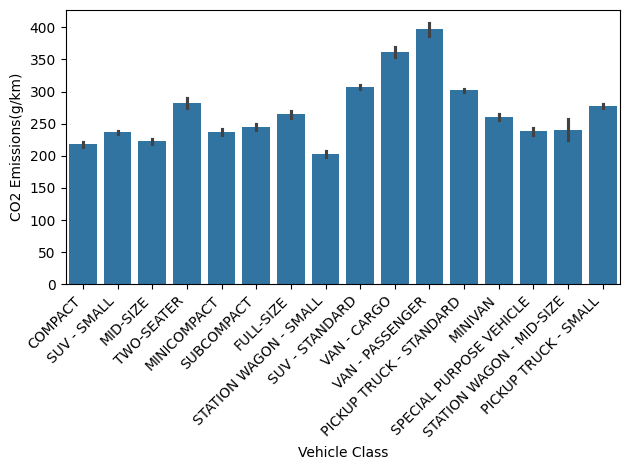

In [459]:
sns.barplot(data=co2_df, x='Vehicle Class', y='CO2 Emissions(g/km)')
plt.xticks(rotation=45, ha='right')  # ha='right' aligns for readability
plt.tight_layout()

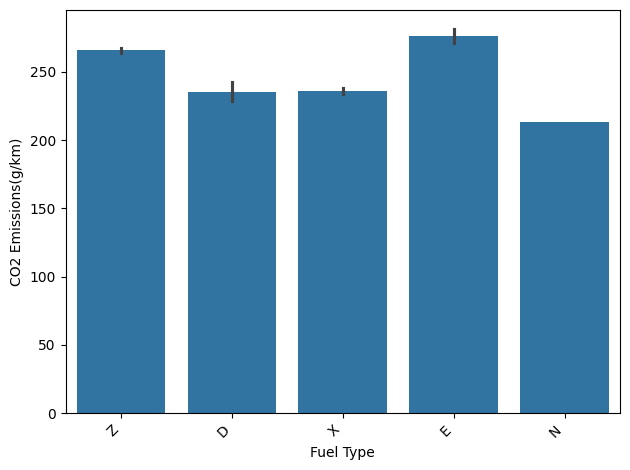

In [460]:
sns.barplot(data=co2_df, x='Fuel Type', y='CO2 Emissions(g/km)')
plt.xticks(rotation=45, ha='right')  # ha='right' aligns for readability
plt.tight_layout()

- Van passenger type vehicle's average co2 emmision is highest
- While vehicle which use Ethanol (E85) fuel has highest average co2 emmision
- Premium gasoline type vehicle have higher co2 emmision as compare to Regular gasoline and Diesel
- Regular gasoline and Diesel category vehicles have almost same co2 emmision


#6. Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.

In [461]:
grouping_cols = ['Vehicle Class', 'Cylinders', 'Fuel Type', 'Engine Size(L)']

# Group by the specified columns and calculate mean and standard deviation of CO2 Emissions
aggregated_co2 = co2_df.groupby(grouping_cols)['CO2 Emissions(g/km)'].agg(
    group_mean_co2=('mean'),
    group_std_co2=('std')
).reset_index()

# Merge the aggregated statistics back to the original DataFrame
co2_df = pd.merge(co2_df, aggregated_co2, on=grouping_cols, how='left')

co2_df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),CO2 Emissions(g/km),group_mean_co2,group_std_co2
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,10.101010,14.925373,11.764706,196,215.625000,18.286046
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,8.928571,12.987013,10.416667,221,205.076923,11.989311
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,16.666667,17.241379,16.949153,136,161.000000,21.435951
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,7.874016,10.989011,9.009009,255,246.280000,18.367816
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,8.264463,11.494253,9.433962,244,246.280000,18.367816


In [462]:
co2_df['co2_z_score'] = (co2_df['CO2 Emissions(g/km)'] - co2_df['group_mean_co2']) / co2_df['group_std_co2']

threshold = 2

co2_df['outlier_status'] = 'Normal'
co2_df.loc[co2_df['co2_z_score'] > threshold, 'outlier_status'] = 'High Outlier'
co2_df.loc[co2_df['co2_z_score'] < -threshold, 'outlier_status'] = 'Low Outlier'

outliers = co2_df[co2_df['outlier_status'] != 'Normal']

print(f"Number of outliers identified: {len(outliers)}")
print("Details of identified outliers:")
outliers_display_cols = [
    'Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
    'Fuel Type', 'Transmission', 'CO2 Emissions(g/km)', 'group_mean_co2',
    'group_std_co2', 'outlier_status'
]
display(outliers[outliers_display_cols].sort_values(by='outlier_status', ascending=False).head())


Number of outliers identified: 221
Details of identified outliers:


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Transmission,CO2 Emissions(g/km),group_mean_co2,group_std_co2,outlier_status
4741,TOYOTA,PRIUS,MID-SIZE,1.8,4,X,AV,105,169.098765,25.893824,Low Outlier
2849,MITSUBISHI,OUTLANDER,SUV - SMALL,2.4,4,X,AV6,193,229.383721,16.137689,Low Outlier
5691,TOYOTA,Highlander Hybrid AWD,SUV - STANDARD,3.5,6,X,AV6,193,286.457143,41.876176,Low Outlier
5692,TOYOTA,Prius,MID-SIZE,1.8,4,X,AV,105,169.098765,25.893824,Low Outlier
2775,MERCEDES-BENZ,B 250,MID-SIZE,2.0,4,Z,AS7,188,219.200000,12.839017,Low Outlier


In [463]:
grouping_cols = ['Vehicle Class', 'Cylinders', 'Fuel Type', 'Engine Size(L)']

In [464]:
grouped_dataframes = {}
for name, group in co2_df.groupby(grouping_cols):
    # Convert the group name tuple to a string for a dictionary key
    key = "_".join(map(str, name))
    grouped_dataframes[key] = group.copy()

print(f"Created {len(grouped_dataframes)} individual DataFrames, stored in 'grouped_dataframes' dictionary.")
# Display the key for one example group and its head to verify
if grouped_dataframes:
    first_key = next(iter(grouped_dataframes))
    print(f"\nExample group key: {first_key}")
    print(f"Head of example group (key: {first_key}):")
    print(grouped_dataframes[first_key].head(2))

Created 376 individual DataFrames, stored in 'grouped_dataframes' dictionary.

Example group key: COMPACT_3_X_1.0
Head of example group (key: COMPACT_3_X_1.0):
      Make  Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
1408  FORD  FOCUS       COMPACT             1.0          3           M6   
2402  FORD  FOCUS       COMPACT             1.0          3          AS6   

     Fuel Type  Fuel Consumption City (km/L)  Fuel Consumption Hwy (km/L)  \
1408         X                     12.345679                    16.949153   
2402         X                     11.764706                    16.949153   

      Fuel Consumption Comb (km/L)  CO2 Emissions(g/km)  group_mean_co2  \
1408                     14.084507                  163      167.714286   
2402                     13.698630                  171      167.714286   

      group_std_co2  co2_z_score outlier_status  
1408       6.550173    -0.719719         Normal  
2402       6.550173     0.501623         Normal  


In [465]:
outlier_grouped_dataframes = {}
for key, df in grouped_dataframes.items():
    if (df['outlier_status'] != 'Normal').any():
        outlier_grouped_dataframes[key] = df

grouped_dataframes = outlier_grouped_dataframes

print(f"Number of DataFrames remaining after removing non-outlier groups: {len(grouped_dataframes)}")
if grouped_dataframes:
    first_key_with_outlier = next(iter(grouped_dataframes))
    print(f"\nExample group with outliers (key: {first_key_with_outlier}):")
    print(grouped_dataframes[first_key_with_outlier].head())

Number of DataFrames remaining after removing non-outlier groups: 89

Example group with outliers (key: COMPACT_4_D_2.0):
            Make                  Model Vehicle Class  Engine Size(L)  \
79           BMW            328d xDRIVE       COMPACT             2.0   
1025  VOLKSWAGEN  BEETLE TDI (modified)       COMPACT             2.0   
1026  VOLKSWAGEN  BEETLE TDI (modified)       COMPACT             2.0   
1043  VOLKSWAGEN   JETTA TDI (modified)       COMPACT             2.0   
1044  VOLKSWAGEN   JETTA TDI (modified)       COMPACT             2.0   

      Cylinders Transmission Fuel Type  Fuel Consumption City (km/L)  \
79            4           A8         D                     13.157895   
1025          4           A6         D                     11.904762   
1026          4           M6         D                     11.363636   
1043          4           A6         D                     12.345679   
1044          4           M6         D                     12.048193   

      

In [466]:
import pandas as pd

# Initialize a flag to check if the condition holds true for all groups
all_high_outlier_less_than_normal = True

print("Comparison of Mean Fuel Consumption Comb (km/L) for High Outliers vs. Normal vehicles per group:\n")

for key, df_group in grouped_dataframes.items():
    # Ensure both 'Normal' and 'High Outlier' statuses exist before comparison
    if 'Normal' in df_group['outlier_status'].unique() and 'High Outlier' in df_group['outlier_status'].unique():
        mean_fuel_consumption = df_group.groupby('outlier_status')['Fuel Consumption Comb (km/L)'].mean()

        mean_normal = mean_fuel_consumption.get('Normal', None)
        mean_high_outlier = mean_fuel_consumption.get('High Outlier', None)

        if mean_normal is not None and mean_high_outlier is not None:
            print(f"Group: {key}")
            print(f"  Mean Fuel Consumption Comb (km/L) for Normal: {mean_normal:.2f}")
            print(f"  Mean Fuel Consumption Comb (km/L) for High Outlier: {mean_high_outlier:.2f}")

            if mean_high_outlier < mean_normal:
                print("  Observation: Mean Fuel Consumption for High Outlier IS LESS than Normal. (Expected for lower efficiency/higher CO2)")
            else:
                print("  Observation: Mean Fuel Consumption for High Outlier IS NOT LESS than Normal. (Unexpected)")
                all_high_outlier_less_than_normal = False
        else:
            print(f"Group: {key} - Missing 'Normal' or 'High Outlier' status for comparison after filtering.")
    else:
        print(f"Group: {key} - Does not contain both 'Normal' and 'High Outlier' statuses for comparison.")
    print("----------------------------------------------------------------------------------------------------")

print(f"\n\nOverall Conclusion: Is mean Fuel Consumption Comb (km/L) for High Outlier always less than Normal? {all_high_outlier_less_than_normal}")

Comparison of Mean Fuel Consumption Comb (km/L) for High Outliers vs. Normal vehicles per group:

Group: COMPACT_4_D_2.0
  Mean Fuel Consumption Comb (km/L) for Normal: 14.59
  Mean Fuel Consumption Comb (km/L) for High Outlier: 12.99
  Observation: Mean Fuel Consumption for High Outlier IS LESS than Normal. (Expected for lower efficiency/higher CO2)
----------------------------------------------------------------------------------------------------
Group: COMPACT_4_E_2.0
  Mean Fuel Consumption Comb (km/L) for Normal: 9.45
  Mean Fuel Consumption Comb (km/L) for High Outlier: 8.62
  Observation: Mean Fuel Consumption for High Outlier IS LESS than Normal. (Expected for lower efficiency/higher CO2)
----------------------------------------------------------------------------------------------------
Group: COMPACT_4_X_1.4
  Mean Fuel Consumption Comb (km/L) for Normal: 13.46
  Mean Fuel Consumption Comb (km/L) for High Outlier: 11.90
  Observation: Mean Fuel Consumption for High Outlier I

In [467]:
import pandas as pd

# Initialize a flag to check if the condition holds true for all groups
all_low_outlier_greater_than_normal = True

print("Comparison of Mean Fuel Consumption Comb (km/L) for Low Outliers vs. Normal vehicles per group:\n")

for key, df_group in grouped_dataframes.items():
    # Ensure both 'Normal' and 'Low Outlier' statuses exist before comparison
    if 'Normal' in df_group['outlier_status'].unique() and 'Low Outlier' in df_group['outlier_status'].unique():
        mean_fuel_consumption = df_group.groupby('outlier_status')['Fuel Consumption Comb (km/L)'].mean()

        mean_normal = mean_fuel_consumption.get('Normal', None)
        mean_low_outlier = mean_fuel_consumption.get('Low Outlier', None)

        if mean_normal is not None and mean_low_outlier is not None:
            print(f"Group: {key}")
            print(f"  Mean Fuel Consumption Comb (km/L) for Normal: {mean_normal:.2f}")
            print(f"  Mean Fuel Consumption Comb (km/L) for Low Outlier: {mean_low_outlier:.2f}")

            if mean_low_outlier > mean_normal:
                print("  Observation: Mean Fuel Consumption for Low Outlier IS GREATER than Normal. (Expected for higher efficiency/lower CO2)")
            else:
                print("  Observation: Mean Fuel Consumption for Low Outlier IS NOT GREATER than Normal. (Unexpected)")
                all_low_outlier_greater_than_normal = False
        else:
            print(f"Group: {key} - Missing 'Normal' or 'Low Outlier' status for comparison after filtering.")
    else:
        print(f"Group: {key} - Does not contain both 'Normal' and 'Low Outlier' statuses for comparison.")
    print("----------------------------------------------------------------------------------------------------")

print(f"\n\nOverall Conclusion: Is mean Fuel Consumption Comb (km/L) for Low Outlier always greater than Normal? {all_low_outlier_greater_than_normal}")

Comparison of Mean Fuel Consumption Comb (km/L) for Low Outliers vs. Normal vehicles per group:

Group: COMPACT_4_D_2.0 - Does not contain both 'Normal' and 'Low Outlier' statuses for comparison.
----------------------------------------------------------------------------------------------------
Group: COMPACT_4_E_2.0 - Does not contain both 'Normal' and 'Low Outlier' statuses for comparison.
----------------------------------------------------------------------------------------------------
Group: COMPACT_4_X_1.4 - Does not contain both 'Normal' and 'Low Outlier' statuses for comparison.
----------------------------------------------------------------------------------------------------
Group: COMPACT_4_X_1.5
  Mean Fuel Consumption Comb (km/L) for Normal: 14.85
  Mean Fuel Consumption Comb (km/L) for Low Outlier: 21.13
  Observation: Mean Fuel Consumption for Low Outlier IS GREATER than Normal. (Expected for higher efficiency/lower CO2)
-----------------------------------------------

For any group of similar vehicle, the mean Fuel Consumption Comb (km/L) for High Outlier always less than normal and for Low outliers always higher than normal. This proves that vehicle with high feul efficianecy tend to have higher co2 emmision and vehicles with low feul efficiency have lower co2 emmision.

#7. Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.

In [468]:
co2_df = co2_df.drop(['group_mean_co2', 'group_std_co2', 'co2_z_score', 'outlier_status'], axis = 1)

In [469]:
co2_df

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,10.101010,14.925373,11.764706,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,8.928571,12.987013,10.416667,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,16.666667,17.241379,16.949153,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,7.874016,10.989011,9.009009,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,8.264463,11.494253,9.433962,244
...,...,...,...,...,...,...,...,...,...,...,...
6277,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,9.345794,12.987013,10.638298,219
6278,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,8.928571,12.048193,10.101010,232
6279,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,8.547009,11.627907,9.708738,240
6280,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,8.928571,12.048193,10.101010,232


In [470]:
cat_col = ['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']
for col in cat_col:
  if co2_df[col].nunique() <=10:
    print(f"  Apply one hot encoding on: {col}")
    print(f"  Unique vlaues in col: {col} is {co2_df[col].nunique()}")
  else:
    print(f"  Apply target encoding on: {col}")
    print(f"  Unique vlaues in col: {col} is {co2_df[col].nunique()}")

#print(f"  Mean Fuel Consumption Comb (km/L) for Normal: {mean_normal:.2f}")

  Apply target encoding on: Make
  Unique vlaues in col: Make is 42
  Apply target encoding on: Model
  Unique vlaues in col: Model is 2053
  Apply target encoding on: Vehicle Class
  Unique vlaues in col: Vehicle Class is 16
  Apply target encoding on: Transmission
  Unique vlaues in col: Transmission is 27
  Apply one hot encoding on: Fuel Type
  Unique vlaues in col: Fuel Type is 5


In the list of categorical colmns ['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Fuel Type'], I will aplly one hot encoding in Feul Type col and on the rest of the col, I will apply target encoding

In [471]:
co2_df= pd.get_dummies(co2_df, columns=['Fuel Type'], drop_first=True, dtype=int)
co2_df

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),CO2 Emissions(g/km),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,ACURA,ILX,COMPACT,2.0,4,AS5,10.101010,14.925373,11.764706,196,0,0,0,1
1,ACURA,ILX,COMPACT,2.4,4,M6,8.928571,12.987013,10.416667,221,0,0,0,1
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,16.666667,17.241379,16.949153,136,0,0,0,1
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,7.874016,10.989011,9.009009,255,0,0,0,1
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,8.264463,11.494253,9.433962,244,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6277,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,9.345794,12.987013,10.638298,219,0,0,0,1
6278,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,8.928571,12.048193,10.101010,232,0,0,0,1
6279,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,8.547009,11.627907,9.708738,240,0,0,0,1
6280,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,8.928571,12.048193,10.101010,232,0,0,0,1


In [472]:
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(co2_df, test_size=0.2, random_state=42)

In [473]:
x_test.shape

(1257, 14)

In [474]:
make_category_wise_mean = x_train.groupby(['Make'])['CO2 Emissions(g/km)'].mean()
model_category_wise_mean = x_train.groupby(['Model'])['CO2 Emissions(g/km)'].mean()
vehicleclass_category_wise_mean = x_train.groupby(['Vehicle Class'])['CO2 Emissions(g/km)'].mean()
transmission_category_wise_mean = x_train.groupby(['Transmission'])['CO2 Emissions(g/km)'].mean()

In [475]:
x_train['Make'] = x_train.groupby('Make')['CO2 Emissions(g/km)'].transform('mean')
x_train['Model'] = x_train.groupby('Model')['CO2 Emissions(g/km)'].transform('mean')
x_train['Vehicle Class'] = x_train.groupby('Vehicle Class')['CO2 Emissions(g/km)'].transform('mean')
x_train['Transmission'] = x_train.groupby('Transmission')['CO2 Emissions(g/km)'].transform('mean')
x_train


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),CO2 Emissions(g/km),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
5845,250.946292,219.000000,235.466667,2.0,4,262.557437,10.000000,12.195122,10.869565,215,0,0,0,1
106,250.946292,289.000000,243.879070,4.4,8,287.310811,6.666667,10.204082,7.874016,292,0,0,0,1
1426,261.877155,259.238095,243.879070,5.0,8,240.596379,6.711409,10.526316,8.064516,285,0,0,1,0
2934,259.915663,222.833333,277.667752,2.7,6,265.036667,9.345794,13.513514,10.869565,217,0,0,0,1
1451,300.385965,428.000000,393.333333,6.0,8,278.619485,4.545455,6.711409,5.319149,432,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,193.805556,178.285714,222.366452,2.5,4,232.745514,10.416667,14.285714,11.904762,198,0,0,1,0
5191,189.902985,178.000000,218.646564,1.5,4,232.745514,11.904762,16.129032,13.513514,173,0,0,0,1
5226,207.208333,204.000000,263.027569,2.0,4,232.745514,10.204082,13.513514,11.494253,207,0,0,1,0
5390,193.805556,182.000000,218.646564,2.0,4,232.745514,11.363636,14.285714,12.500000,186,0,0,1,0


In [476]:
global_mean_co2 = x_train['CO2 Emissions(g/km)'].mean()

x_test['Make'] = x_test['Make'].map(make_category_wise_mean).fillna(global_mean_co2)
x_test['Model'] = x_test['Model'].map(model_category_wise_mean).fillna(global_mean_co2)
x_test['Vehicle Class'] = x_test['Vehicle Class'].map(vehicleclass_category_wise_mean).fillna(global_mean_co2)
x_test['Transmission'] = x_test['Transmission'].map(transmission_category_wise_mean).fillna(global_mean_co2)
x_test

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Consumption City (km/L),Fuel Consumption Hwy (km/L),Fuel Consumption Comb (km/L),CO2 Emissions(g/km),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
2794,279.935593,324.000000,306.806982,3.0,6,278.687225,7.352941,10.000000,8.333333,322,0,0,0,0
5260,274.686047,215.000000,277.667752,3.0,6,262.557437,8.403361,11.764706,9.615385,242,0,0,0,1
2187,264.845455,294.000000,306.806982,3.6,6,240.596379,6.756757,9.615385,7.812500,300,0,0,1,0
5303,248.766234,285.000000,235.466667,3.6,6,287.310811,7.751938,9.803922,8.547009,275,0,0,1,0
3195,250.946292,257.000000,243.879070,3.0,6,265.036667,8.474576,11.235955,9.523810,245,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5507,196.941935,220.000000,238.354839,2.0,4,240.596379,10.638298,13.888889,11.904762,197,0,0,0,1
2364,261.877155,227.571429,235.466667,1.6,4,240.596379,9.523810,12.658228,10.638298,220,0,0,1,0
2952,259.915663,297.000000,263.027569,4.8,8,265.036667,6.493506,10.204082,7.751938,303,0,0,0,1
2252,264.601942,186.833333,218.646564,1.8,4,240.596379,10.416667,14.925373,12.048193,195,0,0,1,0


In [477]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5025 entries, 5845 to 860
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Make                          5025 non-null   float64
 1   Model                         5025 non-null   float64
 2   Vehicle Class                 5025 non-null   float64
 3   Engine Size(L)                5025 non-null   float64
 4   Cylinders                     5025 non-null   int64  
 5   Transmission                  5025 non-null   float64
 6   Fuel Consumption City (km/L)  5025 non-null   float64
 7   Fuel Consumption Hwy (km/L)   5025 non-null   float64
 8   Fuel Consumption Comb (km/L)  5025 non-null   float64
 9   CO2 Emissions(g/km)           5025 non-null   int64  
 10  Fuel Type_E                   5025 non-null   int64  
 11  Fuel Type_N                   5025 non-null   int64  
 12  Fuel Type_X                   5025 non-null   int64  
 13  Fuel T

In [478]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1257 entries, 2794 to 6178
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Make                          1257 non-null   float64
 1   Model                         1257 non-null   float64
 2   Vehicle Class                 1257 non-null   float64
 3   Engine Size(L)                1257 non-null   float64
 4   Cylinders                     1257 non-null   int64  
 5   Transmission                  1257 non-null   float64
 6   Fuel Consumption City (km/L)  1257 non-null   float64
 7   Fuel Consumption Hwy (km/L)   1257 non-null   float64
 8   Fuel Consumption Comb (km/L)  1257 non-null   float64
 9   CO2 Emissions(g/km)           1257 non-null   int64  
 10  Fuel Type_E                   1257 non-null   int64  
 11  Fuel Type_N                   1257 non-null   int64  
 12  Fuel Type_X                   1257 non-null   int64  
 13  Fuel 

In [479]:
from sklearn.preprocessing import StandardScaler
mnmx_scaler = StandardScaler()
df_train = pd.DataFrame(mnmx_scaler.fit_transform(x_train),columns=x_train.columns)

In [480]:
df_test = pd.DataFrame(mnmx_scaler.fit_transform(x_test),columns=x_test.columns)

In [481]:
co2_test_y = df_test["CO2 Emissions(g/km)"]
co2_test_x = df_test.drop(columns=['CO2 Emissions(g/km)'], axis=1)
co2_train_y  = df_train["CO2 Emissions(g/km)"]
co2_train_x = df_train.drop(columns=['CO2 Emissions(g/km)'], axis=1)


#8. Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.

#9. Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.

In [482]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(co2_train_x, co2_train_y)


LinearRegression()

In [483]:
model.coef_

array([ 5.40562308e-04,  6.01535772e-01,  1.77845512e-02,  7.16708645e-02,
        5.87176274e-02, -1.79031939e-02,  4.39575692e-01,  8.46841892e-02,
       -8.28604877e-01, -1.44023617e-01, -4.44089210e-16, -7.77648769e-02,
       -8.65875374e-02])

In [484]:
co2_train_x.shape

(5025, 13)

In [485]:
len(model.coef_)

13

In [486]:
model.intercept_

np.float64(2.6174884396057585e-18)

In [487]:
model.score(co2_train_x, co2_train_y)

0.9754838548071803

In [488]:
model.score(co2_test_x, co2_test_y)

0.888689428494822

In [489]:
if 5 >= model.score(co2_train_x, co2_train_y) - model.score(co2_test_x, co2_test_y):
  print(f'difference between training R_square and test R_square is {(model.score(co2_train_x, co2_train_y) - model.score(co2_test_x, co2_test_y))*100} and model is overfitting')

difference between training R_square and test R_square is 8.679442631235823 and model is overfitting


#Checking feature importance

In [490]:
import numpy as np
feature_importance = pd.Series(abs(model.coef_), co2_train_x.columns).sort_values(ascending=False)
feature_importance

,0
Fuel Consumption Comb (km/L),8.286049e-01
Model,6.015358e-01
Fuel Consumption City (km/L),4.395757e-01
Fuel Type_E,1.440236e-01
Fuel Type_Z,8.658754e-02
Fuel Consumption Hwy (km/L),8.468419e-02
Fuel Type_X,7.776488e-02
Engine Size(L),7.167086e-02
Cylinders,5.871763e-02
Transmission,1.790319e-02


The most important feature to predict co2 emmision is Fuel Consumption Comb (km/L)


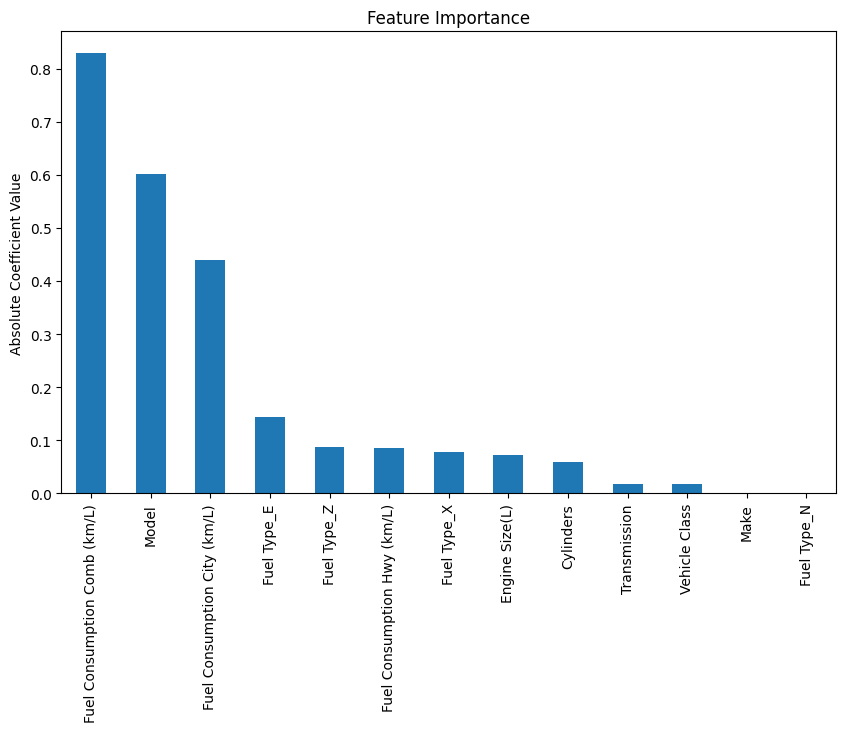

In [491]:
print(f"The most important feature to predict co2 emmision is {feature_importance.index[0]}")
# Plot feature importance
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title('Feature Importance')
plt.ylabel('Absolute Coefficient Value')
plt.show()

Checking VIF

In [492]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["features"] = co2_train_x.columns

In [493]:
co2_train_x.shape[1]

13

In [494]:
co2_train_x.values

array([[ 0.00388457, -0.54941633, -0.43589264, ...,  0.        ,
        -0.97542622,  1.12951991],
       [ 0.00388457,  0.6597561 , -0.19684287, ...,  0.        ,
        -0.97542622,  1.12951991],
       [ 0.30691752,  0.14565218, -0.19684287, ...,  0.        ,
         1.02519286, -0.8853319 ],
       ...,
       [-1.20864931, -0.8085247 ,  0.34728755, ...,  0.        ,
         1.02519286, -0.8853319 ],
       [-1.58021037, -1.18855032, -0.91385854, ...,  0.        ,
         1.02519286, -0.8853319 ],
       [-0.32729877, -0.84739096, -0.43589264, ...,  0.        ,
         1.02519286, -0.8853319 ]])

In [495]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data["VIF"] = [variance_inflation_factor(co2_train_x.values, i) for i in range(co2_train_x.shape[1])]

vif_data

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,features,VIF
0,Make,1.884735
1,Model,12.434844
2,Vehicle Class,2.032274
3,Engine Size(L),9.477211
4,Cylinders,9.008261
5,Transmission,1.639284
6,Fuel Consumption City (km/L),640.964808
7,Fuel Consumption Hwy (km/L),215.261246
8,Fuel Consumption Comb (km/L),1549.970077
9,Fuel Type_E,4.862952


In [496]:
vif_data = vif_data.sort_values(by='VIF',ascending=False).reset_index(drop=True)
vif_data

,features,VIF
0,Fuel Consumption Comb (km/L),1549.970077
1,Fuel Consumption City (km/L),640.964808
2,Fuel Consumption Hwy (km/L),215.261246
3,Fuel Type_X,14.187180
4,Fuel Type_Z,14.151308
5,Model,12.434844
6,Engine Size(L),9.477211
7,Cylinders,9.008261
8,Fuel Type_E,4.862952
9,Vehicle Class,2.032274


In [497]:
print(f'Feature to be remove for colinerity "{vif_data.iloc[0]['features']}"')
print(f'Feature to be remove for colinerity "{vif_data.iloc[1]['features']}"')
print(f'Feature to be remove for colinerity "{vif_data.iloc[2]['features']}"')
print(f'Feature to be remove for colinerity "{vif_data.iloc[3]['features']}"')
print(f'Feature to be remove for colinerity "{vif_data.iloc[4]['features']}"')
print(f'Feature to be remove for colinerity "{vif_data.iloc[5]['features']}"')

Feature to be remove for colinerity "Fuel Consumption Comb (km/L)"
Feature to be remove for colinerity "Fuel Consumption City (km/L)"
Feature to be remove for colinerity "Fuel Consumption Hwy (km/L)"
Feature to be remove for colinerity "Fuel Type_X"
Feature to be remove for colinerity "Fuel Type_Z"
Feature to be remove for colinerity "Model"


In [498]:
co2_test_x = co2_test_x.drop(columns=[vif_data.iloc[0]['features']], axis=1)
co2_train_x = co2_train_x.drop(columns=[vif_data.iloc[0]['features']], axis=1)

co2_test_x = co2_test_x.drop(columns=[vif_data.iloc[1]['features']], axis=1)
co2_train_x = co2_train_x.drop(columns=[vif_data.iloc[1]['features']], axis=1)

co2_test_x = co2_test_x.drop(columns=[vif_data.iloc[2]['features']], axis=1)
co2_train_x = co2_train_x.drop(columns=[vif_data.iloc[2]['features']], axis=1)

co2_test_x = co2_test_x.drop(columns=[vif_data.iloc[3]['features']], axis=1)
co2_train_x = co2_train_x.drop(columns=[vif_data.iloc[3]['features']], axis=1)

co2_test_x = co2_test_x.drop(columns=[vif_data.iloc[4]['features']], axis=1)
co2_train_x = co2_train_x.drop(columns=[vif_data.iloc[4]['features']], axis=1)

co2_test_x = co2_test_x.drop(columns=[vif_data.iloc[5]['features']], axis=1)
co2_train_x = co2_train_x.drop(columns=[vif_data.iloc[5]['features']], axis=1)


In [499]:
co2_train_x.head(2)

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type_E,Fuel Type_N
0,0.003885,-0.435893,-0.849467,-0.873804,0.387818,-0.234536,0.0
1,0.003885,-0.196843,0.913799,1.305285,1.204733,-0.234536,0.0


In [500]:
co2_test_x.head(2)

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type_E,Fuel Type_N
0,0.749110,1.629749,-0.133391,0.170394,0.874234,-0.239146,-0.028217
1,0.607066,0.789747,-0.133391,0.170394,0.329171,-0.239146,-0.028217


In [501]:
model_2 = LinearRegression()
model_2.fit(co2_train_x, co2_train_y)

LinearRegression()

In [502]:
model_2.score(co2_train_x, co2_train_y)

0.8046798329791851

In [503]:
model_2.score(co2_test_x, co2_test_y)

0.809481434307896

In [504]:
if 5 <= abs(model_2.score(co2_train_x, co2_train_y) - model_2.score(co2_test_x, co2_test_y)):
  print(f'difference between training R_square and test R_square is {abs((model_2.score(co2_train_x, co2_train_y) - model_2.score(co2_test_x, co2_test_y))*100)} and model is overfitting')
else:
  print(f'difference between training R_square and test R_square is {abs((model_2.score(co2_train_x, co2_train_y) - model_2.score(co2_test_x, co2_test_y))*100)} and model is not overfitting')

difference between training R_square and test R_square is 0.48016013287108805 and model is not overfitting


#10.Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.

In [505]:
model_2_coefficients = pd.Series(model_2.coef_, co2_train_x.columns)
print("Coefficients of the Linear Regression Model:")
print(model_2_coefficients)

Coefficients of the Linear Regression Model:
Make              0.117667
Vehicle Class     0.219955
Engine Size(L)    0.427844
Cylinders         0.233459
Transmission      0.099171
Fuel Type_E      -0.081813
Fuel Type_N       0.000000
dtype: float64


## Analysis of Linear Regression Model Coefficients

The coefficients of the linear regression model (model_2) quantify the estimated change in CO2 Emissions(g/km) for a one-unit change in the corresponding feature, holding all other features constant. These coefficients help us understand the direction and magnitude of each feature's influence on CO2 emissions.

Here's an interpretation of the coefficients:

*   **Engine Size(L) (Coefficient: 0.427844)**:
    *   **Type**: Numerical feature.
    *   **Interpretation**: A positive coefficient indicates that as the engine size increases, CO2 emissions are predicted to increase. Specifically, for every one-liter increase in 'Engine Size(L)', the model predicts an increase of approximately 0.427844 g/km in CO2 emissions.

*   **Cylinders (Coefficient: 0.233459)**:
    *   **Type**: Numerical feature.
    *   **Interpretation**: A positive coefficient suggests that an increase in the number of cylinders is associated with higher CO2 emissions. For every additional cylinder, the model predicts an increase of approximately 0.233459 g/km in CO2 emissions.

*   **Make (Coefficient: 0.117667)**:
    *   **Type**: Target-encoded categorical feature.
    *   **Interpretation**: This positive coefficient suggests that for 'Makes' with higher encoded average CO2 emissions (from the training data), the predicted CO2 emissions will be higher. A one-unit increase in the target-encoded 'Make' value is associated with an increase of approximately 0.117667 g/km in CO2 emissions.

*   **Vehicle Class (Coefficient: 0.219955)**:
    *   **Type**: Target-encoded categorical feature.
    *   **Interpretation**: Similar to 'Make', this positive coefficient indicates that 'Vehicle Classes' with higher encoded average CO2 emissions are predicted to have higher CO2 emissions. A one-unit increase in the target-encoded 'Vehicle Class' value is associated with an increase of approximately 0.219955 g/km in CO2 emissions.

*   **Transmission (Coefficient: 0.099171)**:
    *   **Type**: Target-encoded categorical feature.
    *   **Interpretation**: This positive coefficient suggests that 'Transmission' types with higher encoded average CO2 emissions are predicted to have higher CO2 emissions. A one-unit increase in the target-encoded 'Transmission' value is associated with an increase of approximately 0.099171 g/km in CO2 emissions.

*   **Fuel Type_E (Coefficient: -0.081813)**:
    *   **Type**: One-hot encoded categorical feature.
    *   **Interpretation**: This negative coefficient indicates that, compared to the base 'Fuel Type' (which was implicitly 'Fuel Type_D' - Diesel - as it was dropped during one-hot encoding with `drop_first=True`), using 'Fuel Type_E' (Ethanol) is associated with a decrease of approximately 0.081813 g/km in CO2 emissions, holding other features constant.

*   **Fuel Type_N (Coefficient: 0.000000)**:
    *   **Type**: One-hot encoded categorical feature.
    *   **Interpretation**: A coefficient of 0 for 'Fuel Type_N' (Natural Gas) indicates that, compared to the base 'Fuel Type' (Diesel), using Natural Gas is associated with virtually no change in CO2 emissions when other factors are held constant. This suggests that its impact on CO2 emissions, given the other features in the model, is negligible or statistically insignificant.

## Evaluation of Model Performance and Key Influencing Factors

### Model Performance Assessment (R-squared)

*   **Training R-squared: 0.80467983**
    *   **Meaning**: This indicates that approximately 80.47% of the variance in CO2 emissions in the training dataset can be explained by the features included in our model.
    *   **Reliability**: A high R-squared on the training set suggests that the model fits the training data well.

*   **Test R-squared: 0.80948143**
    *   **Meaning**: This indicates that approximately 80.95% of the variance in CO2 emissions in the unseen test dataset can be explained by our model.
    *   **Reliability**: A test R-squared close to the training R-squared, and also relatively high, suggests that the model generalizes well to new, unseen data.

*   **Overfitting/Underfitting Observation**:
    *   The difference between the training R-squared (0.80%) and test R-squared (0.809%) is very small (approximately 0.48%). This indicates that the model is **not overfitting** to the training data. The model has learned patterns that are generalizable, and its performance is consistent across both seen and unseen data. This is a good indication of a reliable model.

### Key Factors Influencing CO2 Emissions and Practical Strategies

After addressing multicollinearity (VIF analysis), the refined linear regression model (`model_2`) provides a clearer picture of the most influential factors on CO2 emissions. The columns 'Fuel Consumption Comb (km/L)', 'Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)', 'Fuel Type_X', 'Fuel Type_Z', and 'Model' were removed due to high VIF values, which means they were highly correlated with other predictors, obscuring their individual impact.

Based on the coefficients of `model_2`:

1.  **Engine Size (L) (Coefficient: 0.427844)**:
    *   **Influence**: 'Engine Size(L)' has the largest positive coefficient among the remaining features, indicating it is a significant driver of CO2 emissions. Larger engines produce more CO2.
    *   **Reduction Strategy**: Encourage the adoption of vehicles with smaller, more efficient engines. Technological advancements like turbocharging and direct injection can make smaller engines powerful enough for various applications.

2.  **Cylinders (Coefficient: 0.233459)**:
    *   **Influence**: The number of cylinders also strongly correlates with CO2 emissions. More cylinders typically mean more fuel combustion and thus higher emissions.
    *   **Reduction Strategy**: Promote vehicles with fewer cylinders, or explore technologies like cylinder deactivation that reduce the active number of cylinders during light-load conditions.

3.  **Vehicle Class (Coefficient: 0.219955)**:
    *   **Influence**: 'Vehicle Class' (being target-encoded) shows a substantial positive relationship with CO2 emissions. Vehicle classes with historically higher average CO2 emissions contribute more.
    *   **Reduction Strategy**: Incentivize consumers to choose vehicle classes known for lower emissions (e.g., compacts, subcompacts) over larger, heavier categories (e.g., SUVs, pickup trucks). Implement stricter emissions standards for high-emission vehicle classes.

4.  **Make (Coefficient: 0.117667) and Transmission (Coefficient: 0.099171)**:
    *   **Influence**: 'Make' and 'Transmission' also have positive coefficients, though smaller than engine size and cylinders. Certain manufacturers and transmission types are associated with higher CO2 emissions.
    *   **Reduction Strategy**: Manufacturers with higher average emissions should be encouraged to invest in greener technologies across their product lines. Promote the development and adoption of more efficient transmission systems (e.g., advanced automatics, CVTs) that optimize fuel economy.

5.  **Fuel Type_E (Ethanol) (Coefficient: -0.081813)**:
    *   **Influence**: This negative coefficient, relative to the dropped base 'Fuel Type' (which was 'D' for Diesel), suggests that using Ethanol (E85) can lead to slightly lower CO2 emissions than diesel under similar vehicle characteristics. *Note: The base category was implicitly 'D' from the one-hot encoding.* While the value is small, it indicates a potential benefit.
    *   **Reduction Strategy**: Further research and promotion of alternative fuels like ethanol, considering their overall life-cycle emissions and source sustainability.

6.  **Fuel Type_N (Natural Gas) (Coefficient: 0.000000)**:
    *   **Influence**: A near-zero coefficient indicates that, given other factors, Natural Gas vehicles have an emissions profile very similar to the base fuel type (Diesel) in this model.
    *   **Reduction Strategy**: While not showing a significant *reduction* compared to Diesel in this model, Natural Gas can still be a viable alternative to higher-emission gasoline vehicles, especially if sourced sustainably.

### Overall Conclusion on Emission Reduction:

The most impactful strategies for reducing CO2 emissions, based on this model, revolve around fundamental vehicle characteristics: **reducing engine size, fewer cylinders, and shifting towards smaller vehicle classes**. While fuel types play a role, the core mechanical design and classification of the vehicle have a more substantial and direct influence.